# SentinelVision AI
## Notebook 01 — Data Understanding

### Objective

This notebook establishes a clear understanding of the real-world UCF-Crime data available in the SentinelVision AI pipeline.

The upstream engineering pipeline has already:

1. discovered source video files,
2. extracted technical metadata,
3. validated video usability,
4. assigned leakage-safe train, validation, and test splits,
5. generated temporal clip windows.

This notebook does not repeat those operations.

Instead, it analyzes the generated metadata to answer:

- How many videos are available?
- How many videos passed validation?
- Which categories are represented?
- How imbalanced is the dataset?
- How long are the videos?
- How variable are FPS and resolution?
- Are the train, validation, and test splits balanced?
- How large is the final clip universe?
- What modeling risks must be addressed before feature extraction?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


### Why these libraries?

- `Path` provides clean file-path handling.
- `pandas` is used to inspect the metadata tables created by the pipeline.
- `matplotlib` is used for focused visual analysis.

The notebook intentionally keeps dependencies minimal because this phase is about understanding data, not modeling.

In [2]:
# Define the project metadata directory.
metadata_dir = Path("../data/metadata")

# Define all upstream pipeline outputs used in this notebook.
inventory_path = metadata_dir / "video_inventory.parquet"
valid_videos_path = metadata_dir / "valid_videos.parquet"
invalid_videos_path = metadata_dir / "invalid_videos.parquet"
video_splits_path = metadata_dir / "video_splits.parquet"
clip_manifest_path = metadata_dir / "clip_manifest.parquet"

### Pipeline connection

These files were created before notebook analysis began.

The workflow is:

`raw videos → inventory → validation → video splits → clip manifest → notebook analysis`

This separation prevents the notebook from becoming a hidden data pipeline.

In [3]:
# Store expected files in one dictionary for a clear validation check.
required_files = {
    "video_inventory": inventory_path,
    "valid_videos": valid_videos_path,
    "invalid_videos": invalid_videos_path,
    "video_splits": video_splits_path,
    "clip_manifest": clip_manifest_path,
}

# Check whether every expected file exists.
file_status = pd.DataFrame(
    {
        "dataset": required_files.keys(),
        "path": [str(path) for path in required_files.values()],
        "exists": [path.exists() for path in required_files.values()],
    }
)

file_status

,dataset,path,exists
0,video_inventory,..\data\metadata\video_inventory.parquet,True
1,valid_videos,..\data\metadata\valid_videos.parquet,True
2,invalid_videos,..\data\metadata\invalid_videos.parquet,True
3,video_splits,..\data\metadata\video_splits.parquet,True
4,clip_manifest,..\data\metadata\clip_manifest.parquet,True


In [4]:
# Fail early if an upstream pipeline output is missing.
missing_files = file_status.loc[
    ~file_status["exists"],
    "path",
].tolist()

if missing_files:
    raise FileNotFoundError(
        f"Missing required metadata files: {missing_files}"
    )

print("All required metadata files are available.")

All required metadata files are available.


```text
Notebook started
→ verified upstream outputs
→ confirmed dependencies between phases

### Load the metadata

In [5]:
# Load all metadata generated by the upstream pipeline.
inventory = pd.read_parquet(inventory_path)
valid_videos = pd.read_parquet(valid_videos_path)
invalid_videos = pd.read_parquet(invalid_videos_path)
video_splits = pd.read_parquet(video_splits_path)
clip_manifest = pd.read_parquet(clip_manifest_path)

In [6]:
# Summarize the size of each metadata table.
table_summary = pd.DataFrame(
    {
        "table": [
            "inventory",
            "valid_videos",
            "invalid_videos",
            "video_splits",
            "clip_manifest",
        ],
        "rows": [
            len(inventory),
            len(valid_videos),
            len(invalid_videos),
            len(video_splits),
            len(clip_manifest),
        ],
        "columns": [
            inventory.shape[1],
            valid_videos.shape[1],
            invalid_videos.shape[1],
            video_splits.shape[1],
            clip_manifest.shape[1],
        ],
    }
)

table_summary

,table,rows,columns
0,inventory,1399,16
1,valid_videos,1399,17
2,invalid_videos,0,17
3,video_splits,1399,18
4,clip_manifest,44996,12


### Interpretation

Each table represents a different stage of the pipeline:

- `inventory`: every discovered video inspected by the pipeline.
- `valid_videos`: videos that passed technical and category validation.
- `invalid_videos`: videos rejected from downstream modeling.
- `video_splits`: valid videos assigned to exactly one dataset split.
- `clip_manifest`: temporal windows generated from the frozen video splits.

### Inspect the inventory schema

In [7]:
inventory.head()

,video_id,file_name,file_path,relative_path,parent_folder,category,binary_label,file_extension,file_size_mb,is_readable,fps,frame_count,width,height,duration_seconds,duration_minutes
0,Abuse001_x264,Abuse001_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,20.499,True,30.0,2729,320,240,90.967,1.516
1,Abuse002_x264,Abuse002_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,6.918,True,30.0,865,320,240,28.833,0.481
2,Abuse003_x264,Abuse003_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,24.738,True,30.0,3699,320,240,123.300,2.055
3,Abuse004_x264,Abuse004_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,61.060,True,30.0,16794,320,240,559.800,9.330
4,Abuse005_x264,Abuse005_x264.mp4,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos...,Abuse,Abuse,1,.mp4,5.961,True,30.0,949,320,240,31.633,0.527


In [8]:
# Inspect column names and data types.
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   video_id          1399 non-null   object 
 1   file_name         1399 non-null   object 
 2   file_path         1399 non-null   object 
 3   relative_path     1399 non-null   object 
 4   parent_folder     1399 non-null   object 
 5   category          1399 non-null   object 
 6   binary_label      1399 non-null   int64  
 7   file_extension    1399 non-null   object 
 8   file_size_mb      1399 non-null   float64
 9   is_readable       1399 non-null   bool   
 10  fps               1399 non-null   float64
 11  frame_count       1399 non-null   int64  
 12  width             1399 non-null   int64  
 13  height            1399 non-null   int64  
 14  duration_seconds  1399 non-null   float64
 15  duration_minutes  1399 non-null   float64
dtypes: bool(1), float64(4), int64(4), object(7

In [9]:
# Display the complete inventory column list.
inventory.columns.tolist()

['video_id',
 'file_name',
 'file_path',
 'relative_path',
 'parent_folder',
 'category',
 'binary_label',
 'file_extension',
 'file_size_mb',
 'is_readable',
 'fps',
 'frame_count',
 'width',
 'height',
 'duration_seconds',
 'duration_minutes']

### Why inspect the schema?

Before analyzing distributions, we need to understand what each row represents and which fields are available.

The inventory includes:

- source identity,
- file location,
- category information,
- technical video properties,
- duration,
- readability status.

This metadata becomes the factual foundation for all later modeling work.

In [10]:
# Measure how many discovered videos passed validation.
total_discovered = len(inventory)
total_valid = len(valid_videos)
total_invalid = len(invalid_videos)

validation_rate = (
    total_valid / total_discovered
    if total_discovered > 0
    else 0
)

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Discovered videos",
            "Valid videos",
            "Invalid videos",
            "Validation rate",
        ],
        "value": [
            total_discovered,
            total_valid,
            total_invalid,
            round(validation_rate, 4),
        ],
    }
)

coverage_summary

,metric,value
0,Discovered videos,1399.0
1,Valid videos,1399.0
2,Invalid videos,0.0
3,Validation rate,1.0


In [11]:
# Confirm every valid video received a split assignment.
split_coverage = video_splits["video_id"].nunique()
valid_video_count = valid_videos["video_id"].nunique()

print(f"Valid source videos: {valid_video_count:,}")
print(f"Videos assigned to splits: {split_coverage:,}")
print(
    "All valid videos assigned:",
    valid_video_count == split_coverage,
)

Valid source videos: 1,399
Videos assigned to splits: 1,399
All valid videos assigned: True


In [12]:
# Confirm every split video appears in the clip manifest.
clip_video_coverage = clip_manifest["video_id"].nunique()

print(f"Split source videos: {split_coverage:,}")
print(f"Videos represented by clips: {clip_video_coverage:,}")
print(
    "All split videos represented:",
    split_coverage == clip_video_coverage,
)

Split source videos: 1,399
Videos represented by clips: 1,399
All split videos represented: True


```text
discovered videos
→ validated videos
→ split videos
→ clip-covered videos

#### Category distribution

In [13]:
# Count valid source videos by category.
category_counts = (
    valid_videos["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="video_count")
)

category_counts

,category,video_count
0,RoadAccidents,150
1,Robbery,150
2,Burglary,150
3,Arrest,100
4,Assault,100
5,Abuse,100
6,Arson,100
7,Shooting,100
8,Fighting,100
9,Stealing,100


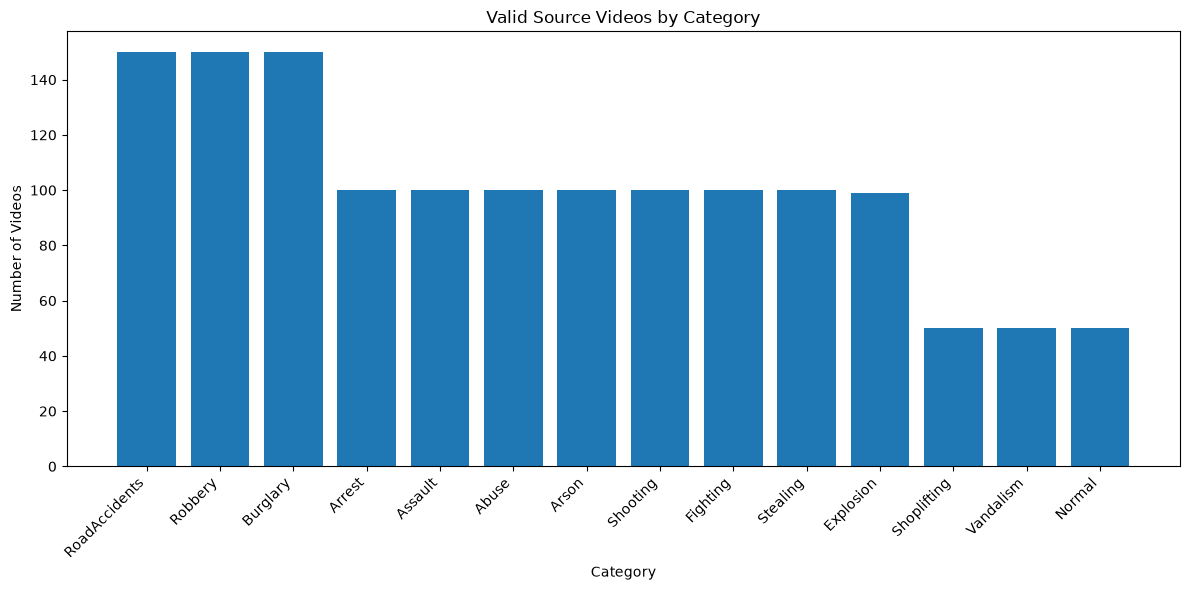

In [14]:
# Plot source-video category counts.
plt.figure(figsize=(12, 6))

plt.bar(
    category_counts["category"],
    category_counts["video_count"],
)

plt.title("Valid Source Videos by Category")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

This chart shows dataset composition at the source-video level.

This is more trustworthy than using clip counts for class balance because longer videos naturally produce more clips.

A category with many clips is not necessarily a category with many independent source videos.

### Binary source-label distribution

In [15]:
# Count valid source videos by binary label.
source_label_counts = (
    valid_videos["binary_label"]
    .value_counts(dropna=False)
    .sort_index()
)

source_label_counts

binary_label
0      50
1    1349
Name: count, dtype: int64

In [16]:
# Convert the source labels into a readable summary.
source_label_summary = pd.DataFrame(
    {
        "label": source_label_counts.index,
        "video_count": source_label_counts.values,
    }
)

source_label_summary["meaning"] = source_label_summary[
    "label"
].map(
    {
        0: "Normal source video",
        1: "Anomalous source video",
    }
)

source_label_summary

,label,video_count,meaning
0,0,50,Normal source video
1,1,1349,Anomalous source video


### Important modeling limitation

The binary label belongs to the source video.

For an anomalous long video:

`source_video_label = 1`

does not mean every 4-second clip contains anomalous behavior.

A long anomalous video may contain:

`normal period → anomaly event → normal period`

Therefore, clip-level modeling must avoid treating inherited video labels as perfect clip ground truth.

This is one reason weakly supervised Multiple Instance Learning is included later in the project.

### Video duration analysis

In [17]:
# Summarize source-video durations.
valid_videos["duration_seconds"].describe()

count    1399.000000
mean      128.617074
std       259.278867
min         3.467000
25%        40.083500
50%        72.967000
75%       133.767000
max      4730.000000
Name: duration_seconds, dtype: float64

In [18]:
# Add minutes for easier interpretation.
duration_minutes = (
    valid_videos["duration_seconds"] / 60
)

duration_minutes.describe()

count    1399.000000
mean        2.143618
std         4.321314
min         0.057783
25%         0.668058
50%         1.216117
75%         2.229450
max        78.833333
Name: duration_seconds, dtype: float64

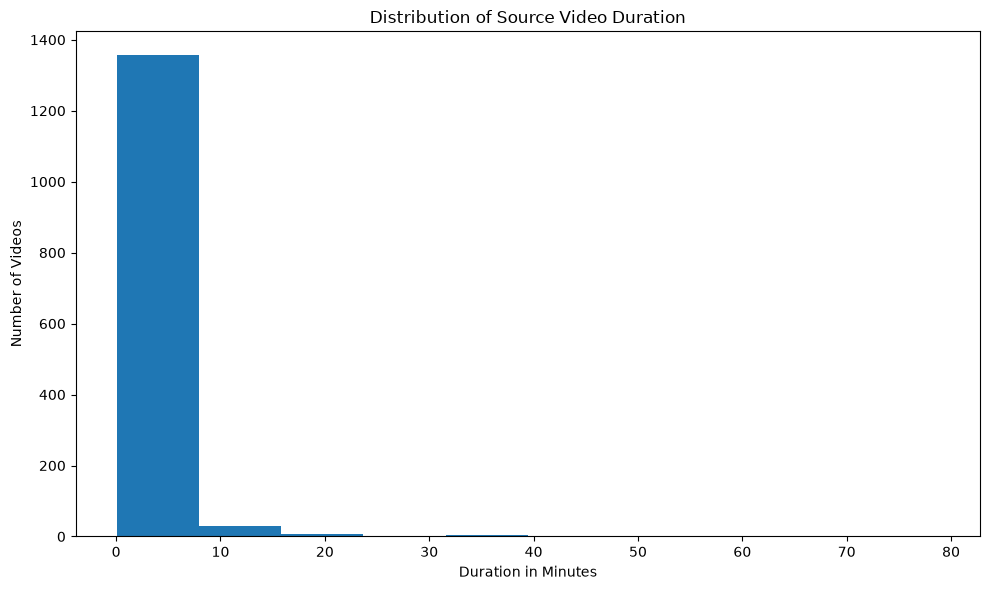

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    duration_minutes
)

plt.title("Distribution of Source Video Duration")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [23]:
# Compare median duration across categories.
category_duration = (
    valid_videos
    .groupby("category")["duration_seconds"]
    .median()
    .sort_values(ascending=False)
    .div(60)
    .rename("median_duration_minutes")
    .reset_index()
)

category_duration

,category,median_duration_minutes
0,Fighting,1.963333
1,Arrest,1.820833
2,Stealing,1.766942
3,Burglary,1.540558
4,Shoplifting,1.538608
5,Abuse,1.494450
6,Arson,1.405833
7,Robbery,1.091942
8,Vandalism,1.080000
9,Shooting,0.997783


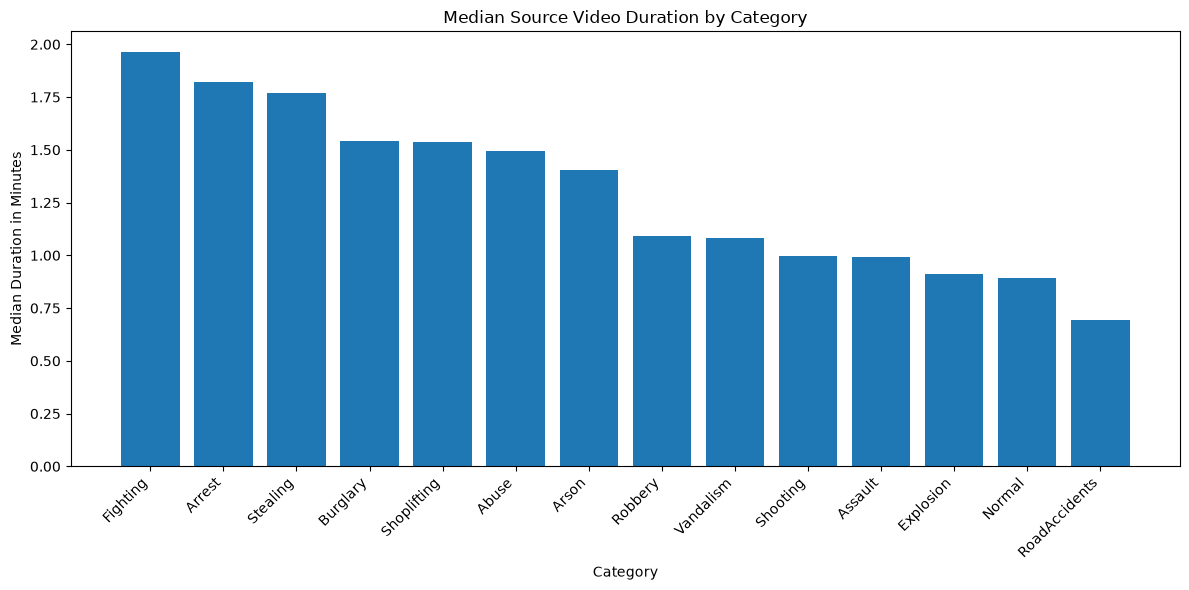

In [24]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_duration["category"],
    category_duration["median_duration_minutes"],
)

plt.title("Median Source Video Duration by Category")
plt.xlabel("Category")
plt.ylabel("Median Duration in Minutes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### FPS analysis

In [26]:
# Summarize frame-rate variation.
valid_videos["fps"].describe()

count    1399.000000
mean       29.999957
std         0.001134
min        29.970000
25%        30.000000
50%        30.000000
75%        30.000000
max        30.000000
Name: fps, dtype: float64

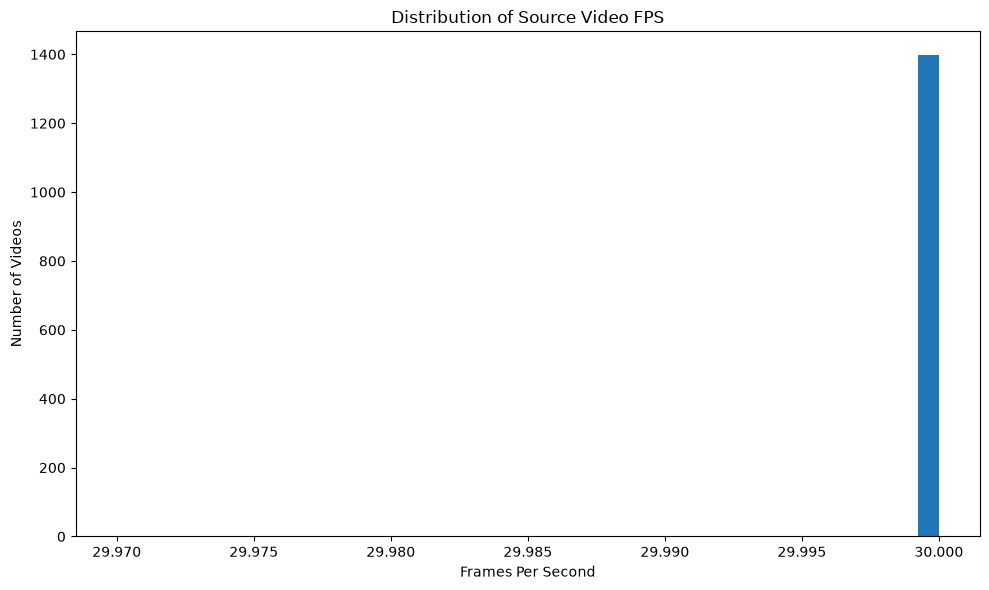

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    valid_videos["fps"],
    bins=40,
)

plt.title("Distribution of Source Video FPS")
plt.xlabel("Frames Per Second")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [28]:
# Show the most common FPS values.
valid_videos["fps"].value_counts().head(15)

fps
30.00    1397
29.97       2
Name: count, dtype: int64

### Why FPS variation matters

Different videos may contain different numbers of frames for the same number of seconds.

For example:

- 4 seconds at 30 FPS contains roughly 120 frames.
- 4 seconds at 15 FPS contains roughly 60 frames.

Deep video models require a fixed temporal tensor shape.

Therefore, later feature extraction will sample a fixed number of frames per clip instead of blindly using every available frame.

#### Resolution analysis

In [30]:
# Create a readable resolution label.
valid_videos = valid_videos.copy()

valid_videos["resolution"] = (
    valid_videos["width"].astype(str)
    + "x"
    + valid_videos["height"].astype(str)
)

In [31]:
# Show the most common source resolutions.
resolution_counts = (
    valid_videos["resolution"]
    .value_counts()
    .head(15)
)

resolution_counts

resolution
320x240    1399
Name: count, dtype: int64

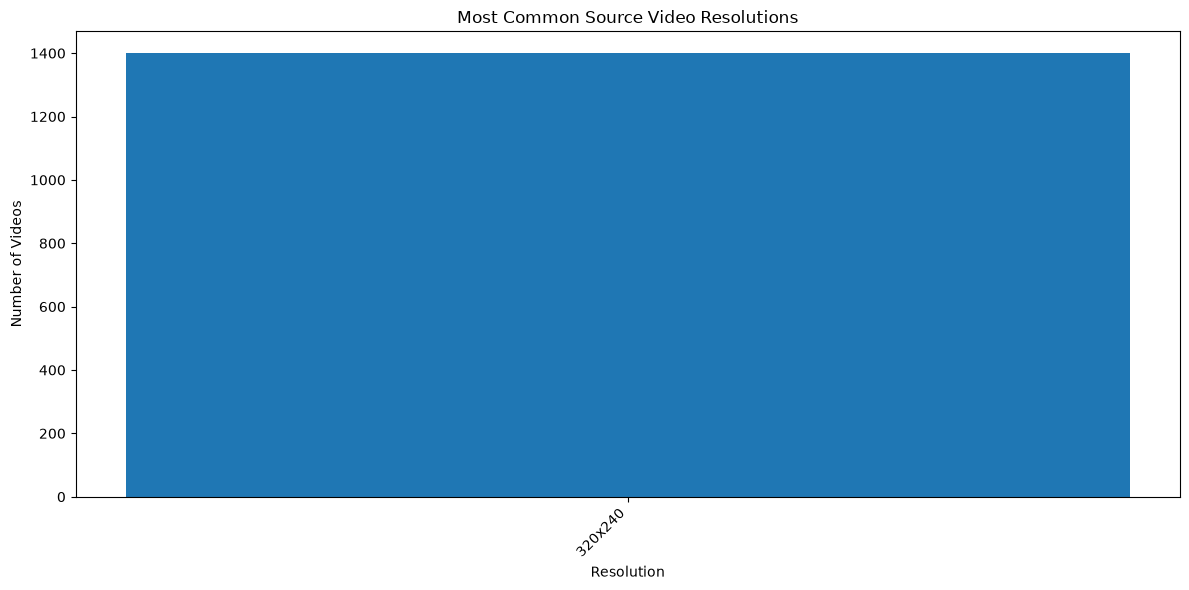

In [32]:
plt.figure(figsize=(12, 6))

plt.bar(
    resolution_counts.index,
    resolution_counts.values,
)

plt.title("Most Common Source Video Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Why resolution variation matters

Neural networks cannot directly batch arbitrary image sizes.

Later preprocessing must transform frames into a consistent spatial shape.

The future feature pipeline will therefore perform:

`decoded frame → resize/crop → tensor → normalization`

This is required before passing clips into a pretrained video backbone.

#### Invalid-video analysis

In [33]:
# Inspect whether any videos failed validation.
print(f"Invalid videos: {len(invalid_videos):,}")

Invalid videos: 0


In [34]:
if invalid_videos.empty:
    print("No invalid videos were recorded.")
else:
    invalid_videos[
        [
            "file_name",
            "category",
            "is_readable",
            "fps",
            "frame_count",
            "duration_seconds",
        ]
    ].head(20)

No invalid videos were recorded.


### Why invalid videos are analyzed separately

Invalid files should not silently enter training.

Possible failure modes include:

- unreadable video containers,
- zero FPS,
- zero frame count,
- invalid dimensions,
- extremely short duration,
- unknown category parsing.

Separating invalid files before modeling improves reliability and makes failures auditable.

#### Split distribution

In [36]:
# Count source videos in each frozen split.
video_split_counts = (
    video_splits["split"]
    .value_counts()
)

video_split_counts

split
train         979
test          210
validation    210
Name: count, dtype: int64

In [37]:
# Calculate source-video split proportions.
video_split_proportions = (
    video_splits["split"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

video_split_proportions

split
train         69.98
test          15.01
validation    15.01
Name: proportion, dtype: float64

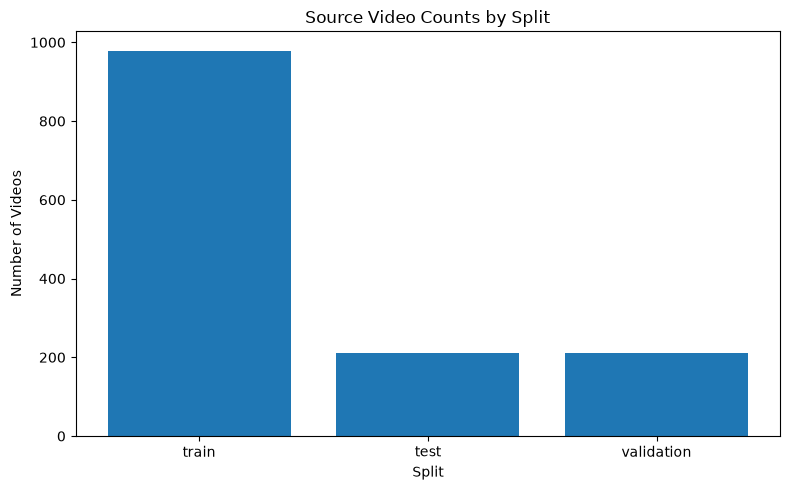

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    video_split_counts.index,
    video_split_counts.values,
)

plt.title("Source Video Counts by Split")
plt.xlabel("Split")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

#### Category balance across splits

In [39]:
# Compare category counts across train, validation, and test.
category_split_table = pd.crosstab(
    video_splits["category"],
    video_splits["split"],
)

category_split_table

split,test,train,validation
category,,,
Abuse,15,70,15
Arrest,15,70,15
Arson,15,70,15
Assault,15,70,15
Burglary,22,105,23
Explosion,15,69,15
Fighting,15,70,15
Normal,7,35,8
RoadAccidents,23,105,22


In [40]:
# Convert category counts into within-category proportions.
category_split_proportions = pd.crosstab(
    video_splits["category"],
    video_splits["split"],
    normalize="index",
).round(3)

category_split_proportions

split,test,train,validation
category,,,
Abuse,0.150,0.700,0.150
Arrest,0.150,0.700,0.150
Arson,0.150,0.700,0.150
Assault,0.150,0.700,0.150
Burglary,0.147,0.700,0.153
Explosion,0.152,0.697,0.152
Fighting,0.150,0.700,0.150
Normal,0.140,0.700,0.160
RoadAccidents,0.153,0.700,0.147


### Interpretation

The split was created at the source-video level.

This protects against leakage because clips from the same original recording never cross train, validation, and test boundaries.

Maintaining source-video integrity is more important than achieving perfectly exact clip-level percentages.

#### Explicit leakage audit

In [41]:
# Count how many different splits each source video appears in.
video_split_membership = (
    video_splits
    .groupby("video_id")["split"]
    .nunique()
)

video_split_membership.value_counts()

split
1    1399
Name: count, dtype: int64

In [42]:
# A valid manifest requires every video to appear in exactly one split.
no_video_leakage = (
    video_split_membership.max() == 1
)

print(
    "No source-video leakage:",
    no_video_leakage,
)

No source-video leakage: True


In [43]:
# Repeat the check after clip generation.
clip_split_membership = (
    clip_manifest
    .groupby("video_id")["split"]
    .nunique()
)

clip_split_membership.value_counts()

split
1    1399
Name: count, dtype: int64

In [44]:
no_clip_stage_leakage = (
    clip_split_membership.max() == 1
)

print(
    "No source-video leakage after clip generation:",
    no_clip_stage_leakage,
)

No source-video leakage after clip generation: True


```text
source-video split
→ preserved after clip generation
→ no video crosses dataset boundaries

#### Clip universe

In [45]:
# Count all generated temporal clips.
total_clips = len(clip_manifest)

print(f"Total temporal clips: {total_clips:,}")

Total temporal clips: 44,996


In [46]:
# Count clips by split.
clip_split_counts = (
    clip_manifest["split"]
    .value_counts()
)

clip_split_counts

split
train         31772
validation     6829
test           6395
Name: count, dtype: int64

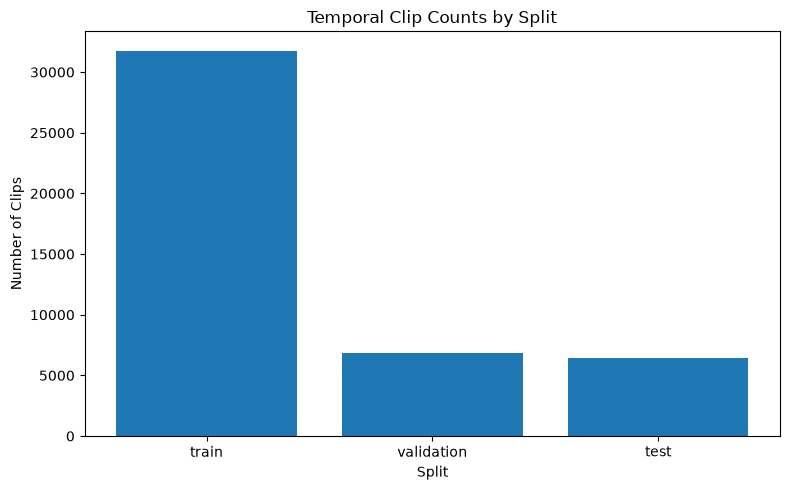

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    clip_split_counts.index,
    clip_split_counts.values,
)

plt.title("Temporal Clip Counts by Split")
plt.xlabel("Split")
plt.ylabel("Number of Clips")
plt.tight_layout()
plt.show()

#### Clips per source video

In [48]:
# Measure how many clips each source video contributes.
clips_per_video = (
    clip_manifest
    .groupby("video_id")
    .size()
    .rename("clip_count")
)

clips_per_video.describe()

count    1399.000000
mean       32.162974
std        64.846991
min         1.000000
25%        10.000000
50%        18.000000
75%        33.000000
max      1183.000000
Name: clip_count, dtype: float64

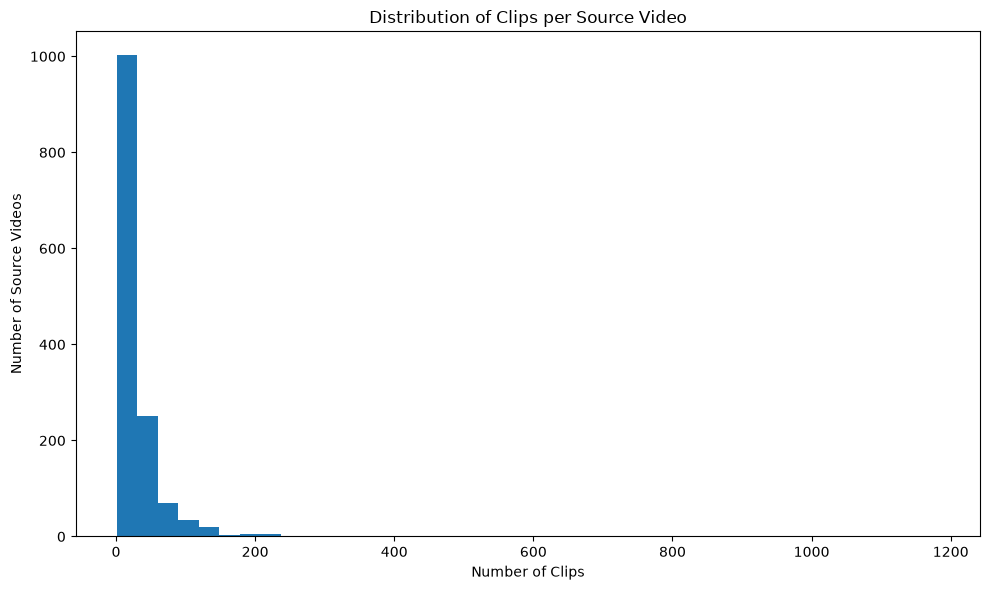

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(
    clips_per_video,
    bins=40,
)

plt.title("Distribution of Clips per Source Video")
plt.xlabel("Number of Clips")
plt.ylabel("Number of Source Videos")
plt.tight_layout()
plt.show()

### Modeling implication

Long source videos contribute more clips than short source videos.

Without careful sampling, the model may become disproportionately influenced by a small number of very long recordings.

Later training pipelines may therefore need:

- video-aware sampling,
- balanced batching,
- capped clips per source video,
- or MIL bag construction.

This decision will be made after feature extraction reveals the actual computational cost.

#### Clip counts by category

In [50]:
# Count clips by source category.
clip_category_counts = (
    clip_manifest["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="clip_count")
)

clip_category_counts

,category,clip_count
0,Burglary,5574
1,Arrest,4958
2,Arson,4524
3,Fighting,4314
4,Stealing,3898
5,Robbery,3524
6,Abuse,3232
7,Explosion,3025
8,Shoplifting,2702
9,Shooting,2462


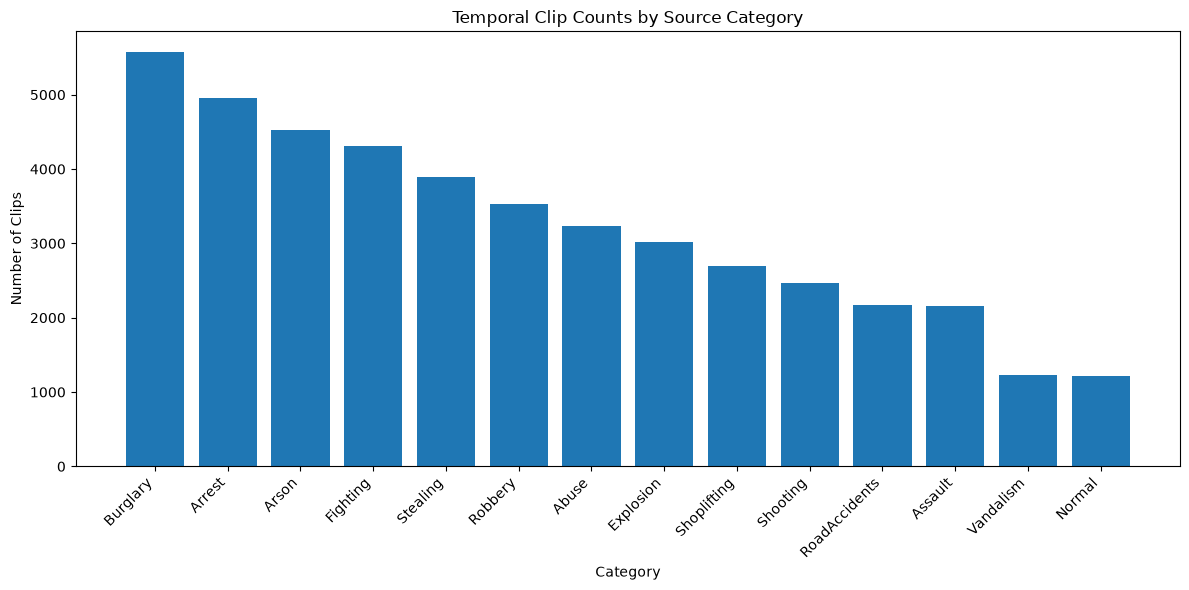

In [51]:
plt.figure(figsize=(12, 6))

plt.bar(
    clip_category_counts["category"],
    clip_category_counts["clip_count"],
)

plt.title("Temporal Clip Counts by Source Category")
plt.xlabel("Category")
plt.ylabel("Number of Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Important distinction

Clip counts measure temporal volume, not independent sample count.

For example:

`one very long video → many clips`

Therefore, source-video counts and clip counts answer different questions:

- source-video counts measure independent recording coverage,
- clip counts measure temporal modeling workload.

#### Label volume at clip level

In [52]:
# Count clips by inherited source-video label.
clip_label_counts = (
    clip_manifest["binary_label"]
    .value_counts()
    .sort_index()
)

clip_label_counts

binary_label
0     1218
1    43778
Name: count, dtype: int64

### Critical interpretation

The large imbalance does not prove that 43,778 clips contain anomalous events.

It means that 43,778 clips originate from videos labeled anomalous at the source-video level.

Because anomalies may occupy only a short period inside a long video, these inherited labels are weak labels.

Consequences:

1. Naive clip-level supervised classification would introduce label noise.
2. Unsupervised baselines should be trained carefully.
3. Temporal sequence modeling becomes important.
4. Weakly supervised MIL remains a strong later-stage model.

Compact project summary